# JET Global Sensitivity Analysis with SALib (Sobol Indices)

This notebook performs a Global Sensitivity Analysis (GSA) of the JET ensemble using ECOSTRESS Collection 2 Cal-Val data and **Sobol indices** via the `SALib` package. It computes first-order ($S_1$) and total-order ($S_T$) indices to rigorously quantify the fractional variance each input variable contributes to model outputs like latent heat flux and evapotranspiration.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import SALib modules for Global Sensitivity Analysis
from SALib.sample import saltelli
from SALib.analyze import sobol
from sklearn.metrics import r2_score, mean_squared_error

# Custom JET modules
from JET3 import process_JET_table, load_ECOv002_calval_JET_inputs

## Configuration and Problem Setup
Load the baseline data and dynamically define the physical boundaries based on the absolute minimum and maximum values of the dataset.

In [2]:
input_variables = [
    "ST_C", "NDVI", "albedo", "Ta_C", "RH", 
    "AOT", "COT", "vapor_gccm", "ozone_cm", 
    "elevation_m", "canopy_height_meters"
]

output_variables = [
    "Rn_Wm2", "ET_daylight_kg"
]

# Load baseline data first
input_df = load_ECOv002_calval_JET_inputs()

# Drop missing values from required inputs
input_df = input_df.dropna(subset=[var for var in input_variables if var in input_df.columns])

# Set bounds using the absolute minimum and maximum of the real data (no filtering applied)
input_min = {var: input_df[var].min() for var in input_variables if var in input_df.columns}
input_max = {var: input_df[var].max() for var in input_variables if var in input_df.columns}

print(f"Total valid rows without filtering: {len(input_df)}")

Total valid rows without filtering: 1061


In [7]:
processed_df = process_JET_table(input_df)

[2026-08-07 17:57:23 INFO] starting JET table processing
[2026-08-07 17:57:23 INFO] started extracting geometry from JET input table
[2026-08-07 17:57:23 INFO] completed extracting geometry from JET input table (0.010 seconds)
[2026-08-07 17:57:23 INFO] started extracting time from JET input table
[2026-08-07 17:57:23 INFO] completed extracting time from JET input table (0.002 seconds)
[2026-08-07 17:57:23 INFO] running Forest Light Environmental Simulator
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[2026-08-07 17:57:23 INFO] completed processing FLiES-ANN in 0.17 seconds
[2026-08-07 17:57:23 INFO] variable PAR_albedo min: 0.003 mean: 0.052 max: 0.681 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable NIR_albedo min: 0.028 mean: 0.164 max: 0.582 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable PAR_direct_Wm2 min: 4.617 mean: 266.198 max: 473.257 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable SWin_FLiES_ANN min: 104.662 mean: 715.359 max: 1153.185 nan: 0.00% (nan)
[2026-08-07 17:

/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/pytho

[2026-08-07 17:57:23 INFO] variable Ps_Pa min: 64923.167 mean: 90433.558 max: 101313.196 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable VPD_Pa min: 9.430 mean: 1744.100 max: 4717.745 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable RH min: 0.273 mean: 0.427 max: 0.985 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable desTa min: 16.249 mean: 177.009 max: 387.676 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable ddesTa min: 1.197 mean: 9.176 max: 17.906 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable gamma min: 42.603 mean: 60.211 max: 68.164 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable Cp min: 1005.693 mean: 1012.865 max: 1022.895 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable rhoa min: 0.776 mean: 1.067 max: 1.314 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable epsa min: 0.658 mean: 0.775 max: 0.971 nan: 0.00% (nan)
[2026-08-07 17:57:23 INFO] variable R min: 10.363 mean: 104.507 max: 1000.000 nan: 0.19% (nan)
[2026-08-07 17:57:23 INFO] variable R

/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/pytho

## Analyze Baseline Data In-Situ Accuracy

In [8]:
import seaborn as sns

# Set Seaborn style for prettier plots
sns.set_theme(style="whitegrid", palette="muted")

def plot_insitu_accuracy(df, variable_name, color=None, model_name=None, cmap="viridis"):
    """
    Generates a scatter plot comparing a single in-situ variable to its model equivalent.
    """
    try:
        insitu_variable = f"insitu_{variable_name}"
        model_prefix = f"{model_name} " if model_name else ""
        print(f"Analyzing {model_prefix}accuracy for {variable_name} compared to {insitu_variable}")
        
        x_variable = insitu_variable
        y_variable = variable_name

        # Check if required columns exist
        required_cols = [x_variable, y_variable]
        if color and color in df.columns:
            required_cols.append(color)
            
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise KeyError(f"Missing required columns in dataframe: {missing_cols}")

        # Filter out rows with NaN values in relevant variables
        valid_data = df[required_cols].dropna()
        
        if valid_data.empty:
            print(f"No valid data remaining after dropping NaNs for {variable_name}. Skipping.")
            return

        # Initialize figure
        plt.figure(figsize=(8, 6))
        
        sc = plt.scatter(
            x=valid_data[x_variable],
            y=valid_data[y_variable],
            c=valid_data[color] if color is not None else None,
            cmap=cmap,
            s=15,
            edgecolor="none",
            alpha=0.8
        )

        # Calculate OLS regression line coefficients
        coefs = np.polyfit(valid_data[x_variable], valid_data[y_variable], 1)

        # Add 1-to-1 line across the entire axis
        plt.axline((0, 0), slope=1, color='gray', linestyle='-', linewidth=1.5, label='1:1 Line')

        # Add OLS regression line across the entire axis
        plt.axline((0, coefs[1]), slope=coefs[0], color='#d62728', linestyle='--', linewidth=2, label='OLS Fit')

        # Calculate R-squared and RMSE
        y_true = valid_data[y_variable]
        y_pred = coefs[0] * valid_data[x_variable] + coefs[1]
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Annotate R-squared and RMSE on plot in lower left corner
        plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
                    xy=(0.05, 0.05), xycoords='axes fraction',
                    ha='left', va='bottom',
                    fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='lightgray', alpha=0.9))

        # Formatting
        plt.xlabel(f"In-Situ {variable_name}", fontsize=11, weight='bold')
        plt.ylabel(f"{model_prefix}{variable_name}", fontsize=11, weight='bold')
        plt.title(f"Accuracy Comparison\nIn-Situ {variable_name} vs {model_prefix}{variable_name}", fontsize=14, weight='bold')
        
        if color:
            plt.colorbar(sc, label=f"{color} Value")
            
        plt.legend(loc='upper left', frameon=True)
        sns.despine(left=True, bottom=True)
        plt.tight_layout()
        plt.show()
        plt.close() # Free memory after displaying
        
    except Exception as e:
        print(f"Error processing {insitu_variable}: {e}")

Analyzing accuracy for Ta_C compared to insitu_Ta_C


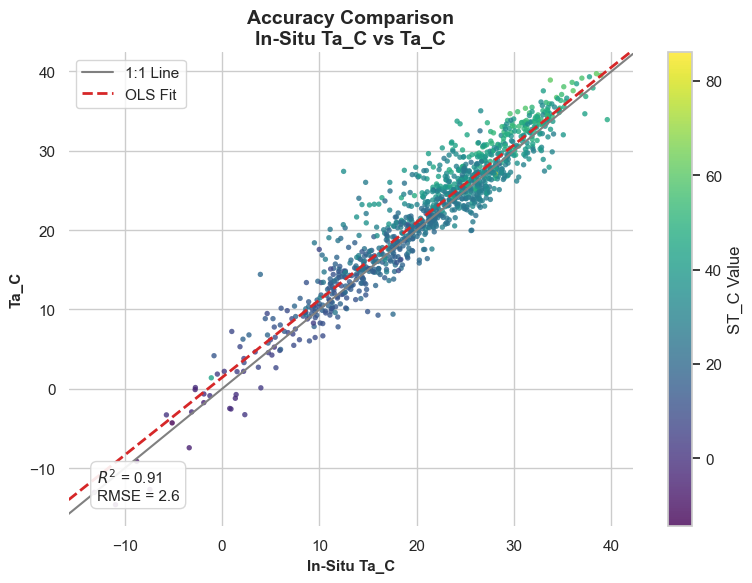

In [9]:
# Generate accuracy plot for Ta_C
plot_insitu_accuracy(processed_df, variable_name="Ta_C", color="ST_C")

Analyzing accuracy for ET_daylight_kg compared to insitu_ET_daylight_kg


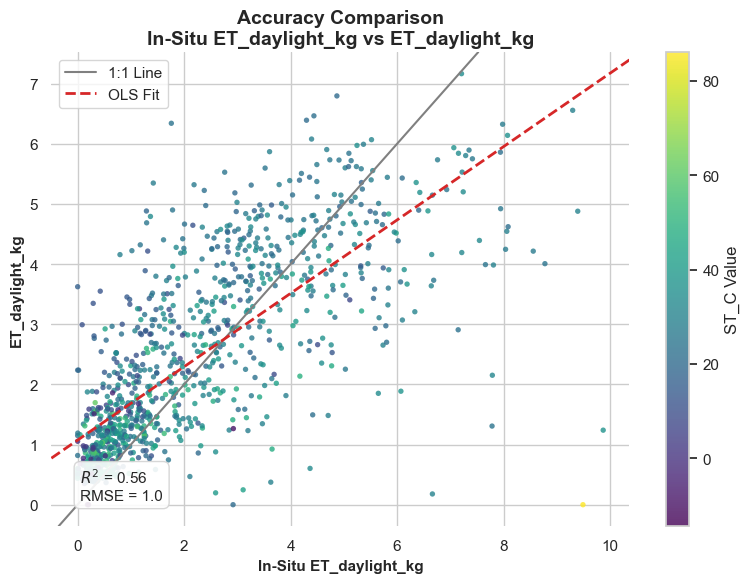

In [10]:
# Generate requested accuracy plot for ET_daylight_kg
plot_insitu_accuracy(processed_df, variable_name="ET_daylight_kg", color="ST_C")

## Generate Saltelli Samples
Construct the problem dictionary and utilize Saltelli's extension of the Sobol sequence to generate parameter values.

In [4]:
problem = {
    'num_vars': len(input_variables),
    'names': input_variables,
    'bounds': [[input_min[var], input_max[var]] for var in input_variables]
}

# Generate Saltelli samples. Total iterations = N * (2D + 2)
# With D=11 and N=256, total model evaluations will be 6,144.
N = 256 
param_values = saltelli.sample(problem, N, calc_second_order=True)

/var/folders/bv/410kt7f93x78j9dww00h1pz80000gn/T/ipykernel_74644/65101988.py:10: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, N, calc_second_order=True)


## Process Samples via the JET Model
We broadcast a static base row from the dataframe to match the Saltelli matrix size, overwrite our input variables with the generated samples, and execute the forward run.

In [5]:
# Construct a sampled DataFrame by repeating a base row
base_row = input_df.iloc[0:1]
sampled_df = pd.concat([base_row] * param_values.shape[0], ignore_index=True)

# Inject the perturbed Sobol variables into the DataFrame
sampled_df[input_variables] = param_values
print(f"Executing {param_values.shape[0]} runs for Global Sensitivity Analysis...")

# Run the forward process
processed_samples = process_JET_table(sampled_df)

Executing 6144 runs for Global Sensitivity Analysis...
[2026-08-07 17:55:44 INFO] starting JET table processing
[2026-08-07 17:55:45 INFO] started extracting geometry from JET input table
[2026-08-07 17:55:45 INFO] completed extracting geometry from JET input table (0.038 seconds)
[2026-08-07 17:55:45 INFO] started extracting time from JET input table
[2026-08-07 17:55:45 INFO] completed extracting time from JET input table (0.003 seconds)
[2026-08-07 17:55:45 INFO] running Forest Light Environmental Simulator
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 254us/step
[2026-08-07 17:55:45 INFO] completed processing FLiES-ANN in 0.40 seconds
[2026-08-07 17:55:45 INFO] variable PAR_albedo (float64) with [0.09390986] unique values
[2026-08-07 17:55:45 INFO] * 0.0939098562443398: 6144
[2026-08-07 17:55:45 INFO] variable NIR_albedo (float64) with [0.35587504] unique values
[2026-08-07 17:55:45 INFO] * 0.3558750381101216: 6144
[2026-08-07 17:55:45 INFO] variable PAR_direct_Wm2 min: 2.934 mean: 26.668 max: 2

/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/pytho

[2026-08-07 17:55:46 INFO] completed daylight ET upscaling (PMJPL)
[2026-08-07 17:55:46 INFO] completed processing PM-JPL in 0.17 seconds
[2026-08-07 17:55:46 INFO] variable LE_PMJPL_Wm2 min: 0.000 mean: 47.860 max: 540.463 nan: 8.59% (nan)
[2026-08-07 17:55:46 INFO] variable ET_daylight_PMJPL_kg min: 0.000 mean: 0.523 max: 5.549 nan: 8.59% (nan)
[2026-08-07 17:55:46 INFO] variable G_PMJPL_Wm2 min: -0.000 mean: 3.927 max: 103.297 nan: 8.59% (nan)
[2026-08-07 17:55:46 INFO] variable ET_daylight_kg min: 0.000 mean: 0.484 max: 6.834 nan: 0.00% (nan)
[2026-08-07 17:55:46 INFO] JET table processing complete (1.365 seconds)


/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:212: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  doy_UTC = ((times_b.astype('datetime64[D]') - year_start.astype('datetime64[D]')) + 1).astype(int)
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/python3.13/site-packages/solar_apparent_time/solar_apparent_time.py:37: UserWarning: no explicit representation of timezones available for np.datetime64
  return np.array(arr, dtype='datetime64[ns]')
/opt/homebrew/Caskroom/miniforge/base/envs/JET3/lib/pytho

## Analyze and Visualize Sobol Indices
We extract the target array, analyze the outputs via the Sobol library, and map the First-Order and Total-Order variance percentages into a comparison chart.

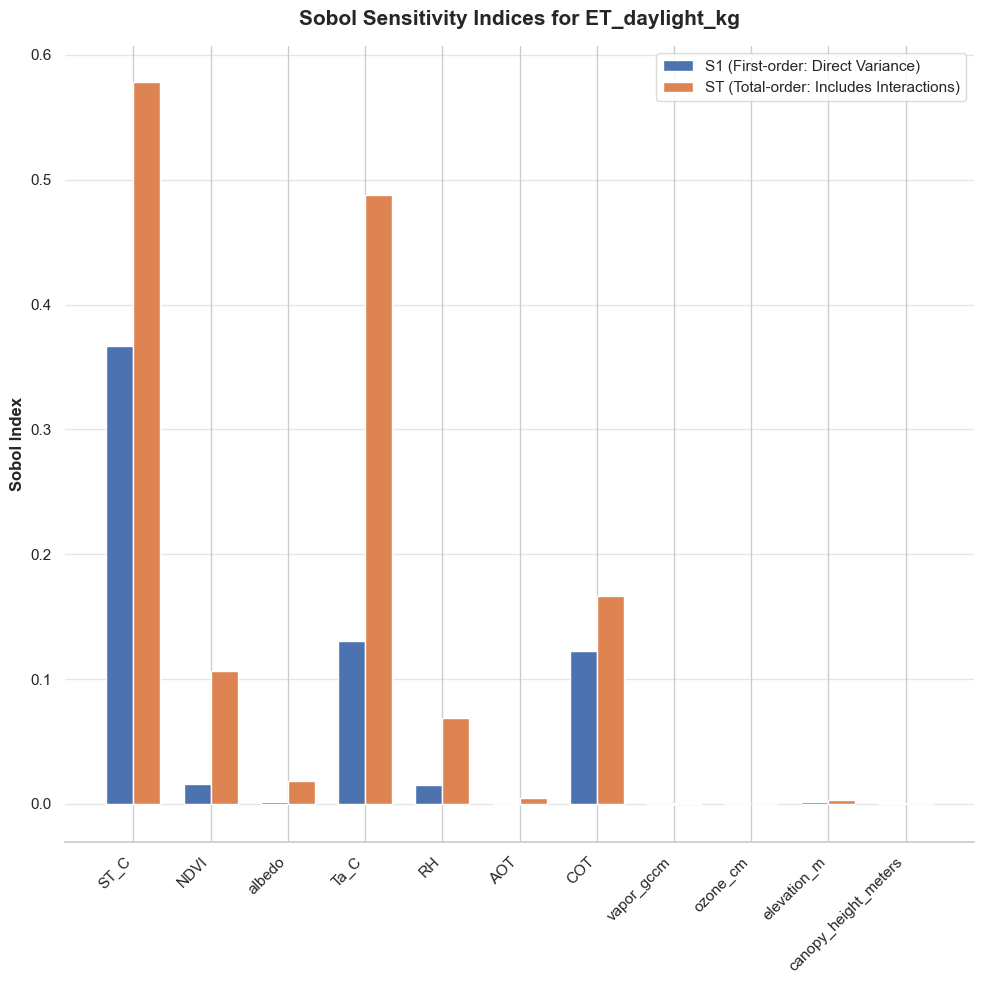

In [11]:
# Set Seaborn style for the bar chart
sns.set_theme(style="whitegrid")
colors = sns.color_palette("deep")

target_output = "ET_daylight_kg"
Y = processed_samples[target_output].values

# Calculate Sobol indices
Si = sobol.analyze(problem, Y, calc_second_order=True)

# Visualizing First-Order and Total-Order Indices
# Updated figsize to (10, 10) for a square aspect ratio
fig, ax = plt.subplots(figsize=(10, 10)) 
x = np.arange(len(input_variables))
width = 0.35

ax.bar(x - width/2, Si['S1'], width, label='S1 (First-order: Direct Variance)', color=colors[0], edgecolor="white", linewidth=1)
ax.bar(x + width/2, Si['ST'], width, label='ST (Total-order: Includes Interactions)', color=colors[1], edgecolor="white", linewidth=1)

ax.set_ylabel('Sobol Index', fontsize=12, weight='bold')
ax.set_title(f'Sobol Sensitivity Indices for {target_output}', fontsize=15, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(input_variables, rotation=45, ha='right', fontsize=11)
ax.legend(frameon=True, facecolor='white', edgecolor='lightgray')

# Remove top and right borders for a cleaner look
sns.despine(left=True)
ax.grid(axis='y', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()